In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yfin
from datetime import datetime

# 1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day) #current date month and last 10 years 
end = now
ticker = 'AAPL'
dataFrame = yfin.download(ticker, start, end)
dataFrame

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-25,22.159418,22.500893,22.063806,22.366580,161531600
2016-07-26,22.006889,22.302835,21.949977,22.041037,224959200
2016-07-27,23.436529,23.755239,23.391000,23.737027,369379200
2016-07-28,23.752960,23.778002,23.406934,23.409211,159479200
2016-07-29,23.723373,23.800775,23.602719,23.718821,110934800
...,...,...,...,...,...
2026-07-17,333.739990,334.989990,329.000000,331.980011,63407100
2026-07-20,326.589996,333.709991,323.679993,333.510010,53468000


# 2. Data Exploration and Visualization

In [3]:
dataFrame

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-25,22.159418,22.500893,22.063806,22.366580,161531600
2016-07-26,22.006889,22.302835,21.949977,22.041037,224959200
2016-07-27,23.436529,23.755239,23.391000,23.737027,369379200
2016-07-28,23.752960,23.778002,23.406934,23.409211,159479200
2016-07-29,23.723373,23.800775,23.602719,23.718821,110934800
...,...,...,...,...,...
2026-07-17,333.739990,334.989990,329.000000,331.980011,63407100
2026-07-20,326.589996,333.709991,323.679993,333.510010,53468000


In [4]:
type(dataFrame)

pandas.core.frame.DataFrame

In [5]:
dataFrame.shape

(2513, 5)

In [6]:
dataFrame.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
dataFrame.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-25,22.159418,22.500893,22.063806,22.366580,161531600
2016-07-26,22.006889,22.302835,21.949977,22.041037,224959200
2016-07-27,23.436529,23.755239,23.391000,23.737027,369379200
2016-07-28,23.752960,23.778002,23.406934,23.409211,159479200
2016-07-29,23.723373,23.800775,23.602719,23.718821,110934800


In [8]:
dataFrame = dataFrame.reset_index()  #Reset the index of the DataFrame, and use the default one instead. 
dataFrame.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-07-25,22.159418,22.500893,22.063806,22.366580,161531600
1,2016-07-26,22.006889,22.302835,21.949977,22.041037,224959200
2,2016-07-27,23.436529,23.755239,23.391000,23.737027,369379200
3,2016-07-28,23.752960,23.778002,23.406934,23.409211,159479200
4,2016-07-29,23.723373,23.800775,23.602719,23.718821,110934800


Text(0, 0.5, 'Close Price')

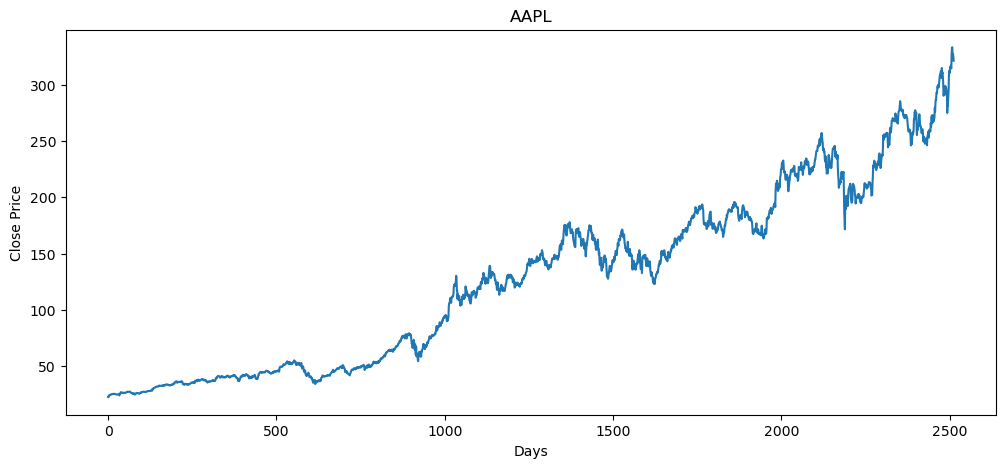

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(dataFrame.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')

# 3. Feature Engineering

In [10]:
df = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [11]:
df['MA_5'] = df.rolling(5).mean()  #rolling is a function to calculate moving average
df

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 Days Moving Average

In [12]:
dataFrame['MA_100']= dataFrame[('Close', 'AAPL')].rolling(100).mean() #first 99 will be NaN and then start calculating
dataFrame.head(105)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-07-25,22.159418,22.500893,22.063806,22.366580,161531600,NaN
1,2016-07-26,22.006889,22.302835,21.949977,22.041037,224959200,NaN
2,2016-07-27,23.436529,23.755239,23.391000,23.737027,369379200,NaN
3,2016-07-28,23.752960,23.778002,23.406934,23.409211,159479200,NaN
4,2016-07-29,23.723373,23.800775,23.602719,23.718821,110934800,NaN
...,...,...,...,...,...,...,...
100,2016-12-14,26.500378,26.732735,26.452066,26.465869,136127200,25.377077
101,2016-12-15,26.645319,26.854673,26.509586,26.544093,186098000,25.423461
102,2016-12-16,26.679829,26.801759,26.606210,26.794858,177404400,25.455894


Text(0, 0.5, 'Price')

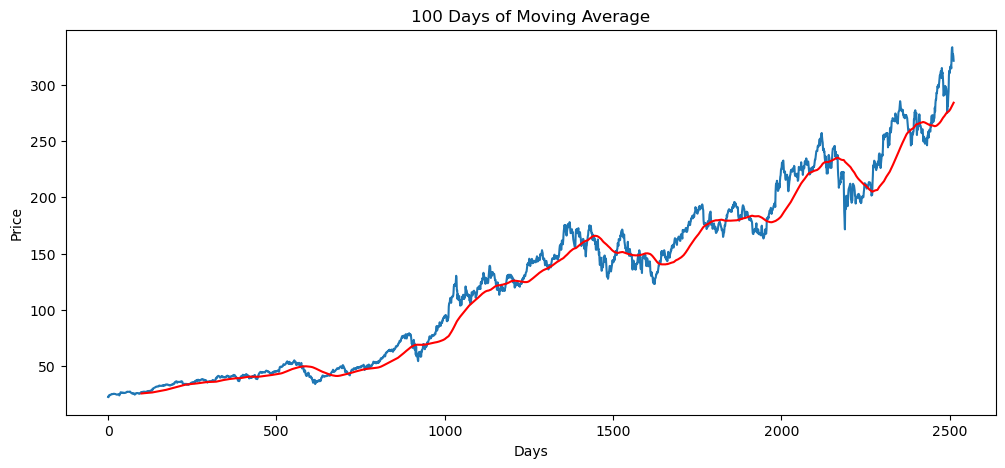

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(dataFrame.Close)
plt.plot(dataFrame['MA_100'], 'r')
plt.title("100 Days of Moving Average")
plt.xlabel('Days')
plt.ylabel('Price')

### 200 Days Moving Average

In [14]:
dataFrame['MA_200'] = dataFrame[('Close', 'AAPL')].rolling(200).mean()
dataFrame.head(201)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-25,22.159418,22.500893,22.063806,22.366580,161531600,NaN,NaN
1,2016-07-26,22.006889,22.302835,21.949977,22.041037,224959200,NaN,NaN
2,2016-07-27,23.436529,23.755239,23.391000,23.737027,369379200,NaN,NaN
3,2016-07-28,23.752960,23.778002,23.406934,23.409211,159479200,NaN,NaN
4,2016-07-29,23.723373,23.800775,23.602719,23.718821,110934800,NaN,NaN
...,...,...,...,...,...,...,...,...
196,2017-05-04,33.856537,33.997481,33.690177,33.854228,93487600,30.469188,NaN
197,2017-05-05,34.418026,34.422645,33.909701,33.909701,109310800,30.551217,NaN
198,2017-05-08,35.353790,35.513219,34.434191,34.434191,195009600,30.644099,NaN


Text(0, 0.5, 'Price')

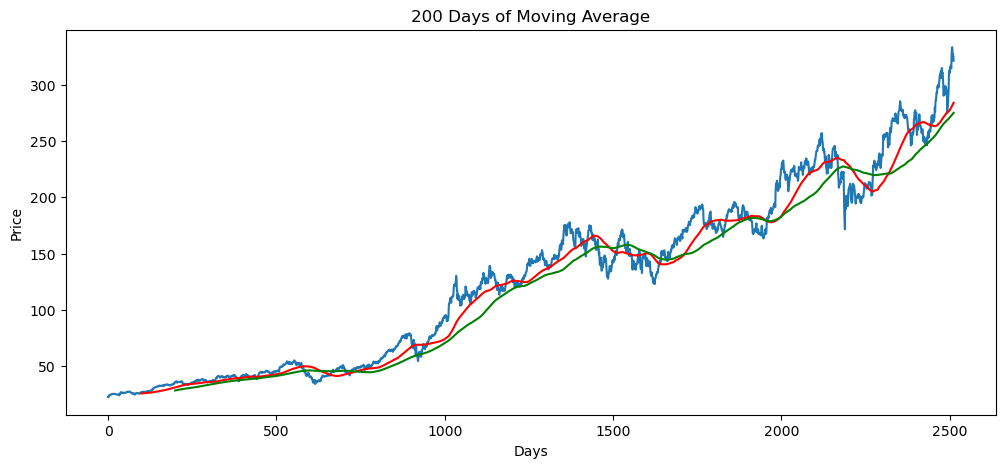

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(dataFrame.Close)
plt.plot(dataFrame['MA_100'], 'r')
plt.plot(dataFrame['MA_200'], 'g')
plt.title('200 Days of Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

In [16]:
dataFrame

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-25,22.159418,22.500893,22.063806,22.366580,161531600,NaN,NaN
1,2016-07-26,22.006889,22.302835,21.949977,22.041037,224959200,NaN,NaN
2,2016-07-27,23.436529,23.755239,23.391000,23.737027,369379200,NaN,NaN
3,2016-07-28,23.752960,23.778002,23.406934,23.409211,159479200,NaN,NaN
4,2016-07-29,23.723373,23.800775,23.602719,23.718821,110934800,NaN,NaN
...,...,...,...,...,...,...,...,...
2508,2026-07-17,333.739990,334.989990,329.000000,331.980011,63407100,282.107506,273.880447
2509,2026-07-20,326.589996,333.709991,323.679993,333.510010,53468000,282.654511,274.243839
2510,2026-07-21,327.739990,329.600006,322.220001,323.130005,41338900,283.192135,274.608892


### Calculating % changed in each trading session

In [17]:
dataFrame['Percentage Changed'] = dataFrame.Close.pct_change()
dataFrame[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,22.159418,NaN
1,22.006889,-0.006883
2,23.436529,0.064963
3,23.752960,0.013502
4,23.723373,-0.001246
...,...,...
2508,333.739990,0.001440
2509,326.589996,-0.021424
2510,327.739990,0.003521


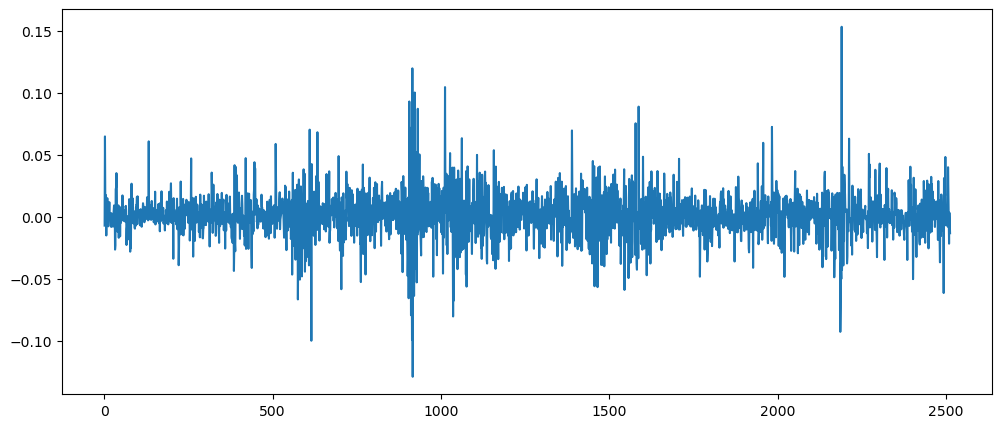

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(dataFrame['Percentage Changed'])

# 4. Data Preprocessing

In [19]:
dataFrame.shape

(2513, 9)

### Splitting data into training and testing datasets

In [20]:
dataTraining = pd.DataFrame(dataFrame.Close[0:int(len(dataFrame)*0.7)])
dataTesting = pd.DataFrame(dataFrame.Close[int(len(dataFrame)*0.7): int(len(dataFrame))])
dataTraining

Ticker,AAPL
0,22.159418
1,22.006889
2,23.436529
3,23.752960
4,23.723373
...,...
1754,188.053604
1755,191.308029
1756,191.051575
1757,192.402664


In [21]:
dataTesting

Ticker,AAPL
1759,189.286362
1760,190.085159
1761,190.943115
1762,191.810944
1763,190.548660
...,...
2508,333.739990
2509,326.589996
2510,327.739990
2511,325.890015


In [22]:
# Scaling down the data between 0 & 1

In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [24]:
data_training_array = scaler.fit_transform(dataTraining)
data_training_array

array([[8.95144043e-04],
       [0.00000000e+00],
       [8.39011306e-03],
       ...,
       [9.92070875e-01],
       [1.00000000e+00],
       [9.88598429e-01]], shape=(1759, 1))

In [25]:
data_training_array.shape

(1759, 1)

# 5. Sequence Creation

In [26]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [27]:
x_train

array([[[8.95144043e-04],
        [0.00000000e+00],
        [8.39011306e-03],
        ...,
        [2.46967364e-02],
        [2.38191663e-02],
        [2.63708905e-02]],

       [[0.00000000e+00],
        [8.39011306e-03],
        [1.02471488e-02],
        ...,
        [2.38191663e-02],
        [2.63708905e-02],
        [2.63708905e-02]],

       [[8.39011306e-03],
        [1.02471488e-02],
        [1.00735131e-02],
        ...,
        [2.63708905e-02],
        [2.63708905e-02],
        [2.72215062e-02]],

       ...,

       [[7.31482532e-01],
        [7.34314433e-01],
        [7.18767545e-01],
        ...,
        [9.73608804e-01],
        [9.74476714e-01],
        [9.93575926e-01]],

       [[7.34314433e-01],
        [7.18767545e-01],
        [7.25760792e-01],
        ...,
        [9.74476714e-01],
        [9.93575926e-01],
        [9.92070875e-01]],

       [[7.18767545e-01],
        [7.25760792e-01],
        [7.22813105e-01],
        ...,
        [9.93575926e-01],
        [9.9207

In [28]:
y_train

array([0.02637089, 0.02722151, 0.02742403, ..., 0.99207087, 1.        ,
       0.98859843], shape=(1659,))

In [29]:
x_train.ndim


3

In [30]:
y_train.ndim

1

In [31]:
x_train.shape

(1659, 100, 1)

In [32]:
y_train.shape

(1659,)

# 6. Model Building

In [33]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [34]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [35]:
model = Sequential()

model.add(Input(shape=(100, 1))) #100 is previous 100 days of data
# hyperbolic tangent it handles both positive and negative values, 
# return_sequences=True means it should return full sequence
model.add(LSTM(units=128, activation='tanh', return_sequences=True)) 
# By default return_sequences=False means it will generate only one summary of data, which means it will give the single value
model.add(LSTM(units=64)) 
# it will take LSTM single output and analyse it in 25 different angles and then it will pass the findings to the next layer
model.add(Dense(25))
model.add(Dense(1)) # it will give a single final prediction output

# 7. Model Training

In [36]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50) #epochs means asking model to go through x_train and y_train 50 times.

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - loss: 0.0141
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - loss: 6.7931e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - loss: 6.3993e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step - loss: 6.2453e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - loss: 5.9718e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - loss: 5.5997e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 5.6034e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 5.4706e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - loss: 4.6908e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - loss: 4.7741e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 4.4521e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - loss: 4.7459e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 4.6482e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - loss: 4.3049e-04

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [38]:
# save the trained model
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [39]:
dataTraining

Ticker,AAPL
0,22.159418
1,22.006889
2,23.436529
3,23.752960
4,23.723373
...,...
1754,188.053604
1755,191.308029
1756,191.051575
1757,192.402664


In [40]:
dataTesting

Ticker,AAPL
1759,189.286362
1760,190.085159
1761,190.943115
1762,191.810944
1763,190.548660
...,...
2508,333.739990
2509,326.589996
2510,327.739990
2511,325.890015


In [41]:
past_100_days = dataTraining.tail(100)
past_100_days

Ticker,AAPL
1659,145.673462
1660,145.171188
1661,143.103058
1662,143.693985
1663,148.736206
...,...
1754,188.053604
1755,191.308029
1756,191.051575
1757,192.402664


In [42]:
final_df = pd.concat([past_100_days, dataTesting], ignore_index=True)
final_df

Ticker,AAPL
0,145.673462
1,145.171188
2,143.103058
3,143.693985
4,148.736206
...,...
849,333.739990
850,326.589996
851,327.739990
852,325.890015


In [43]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.01348324],
       [0.01084853],
       [0.        ],
       [0.00309975],
       [0.02954909],
       [0.0440138 ],
       [0.03249372],
       [0.03905429],
       [0.02727616],
       [0.01647942],
       [0.02665625],
       [0.03760795],
       [0.03967445],
       [0.05444884],
       [0.05005778],
       [0.06245623],
       [0.07216785],
       [0.06467745],
       [0.07035997],
       [0.07717883],
       [0.06700208],
       [0.06374745],
       [0.07986501],
       [0.08807874],
       [0.10120036],
       [0.10776101],
       [0.10497134],
       [0.0953111 ],
       [0.09996052],
       [0.08637411],
       [0.08002005],
       [0.07640387],
       [0.10460971],
       [0.10280182],
       [0.102905  ],
       [0.1093106 ],
       [0.11530336],
       [0.1102406 ],
       [0.1018202 ],
       [0.10342166],
       [0.09536288],
       [0.0953111 ],
       [0.11933263],
       [0.1258932 ],
       [0.1254284 ],
       [0.12000401],
       [0.11437336],
       [0.105

In [44]:
input_data.shape

(854, 1)

In [45]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [46]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [47]:
x_test

array([[[0.01348324],
        [0.01084853],
        [0.        ],
        ...,
        [0.25151746],
        [0.2586047 ],
        [0.24841371]],

       [[0.01084853],
        [0.        ],
        [0.00309975],
        ...,
        [0.2586047 ],
        [0.24841371],
        [0.2422579 ]],

       [[0.        ],
        [0.00309975],
        [0.02954909],
        ...,
        [0.24841371],
        [0.2422579 ],
        [0.24644806]],

       ...,

       [[0.686512  ],
        [0.67980376],
        [0.6338424 ],
        ...,
        [0.99748223],
        [1.        ],
        [0.96249418]],

       [[0.67980376],
        [0.6338424 ],
        [0.63667233],
        ...,
        [1.        ],
        [0.96249418],
        [0.96852656]],

       [[0.6338424 ],
        [0.63667233],
        [0.63158892],
        ...,
        [0.96249418],
        [0.96852656],
        [0.95882238]]], shape=(754, 100, 1))

In [48]:
y_test

array([0.2422579 , 0.24644806, 0.25094853, 0.25550078, 0.24887938,
       0.26238096, 0.26558836, 0.26124293, 0.24556864, 0.23827466,
       0.19078596, 0.1745425 , 0.17945702, 0.1711285 , 0.16999032,
       0.17030112, 0.17895196, 0.16853982, 0.16398155, 0.15066888,
       0.15320706, 0.16020001, 0.16740035, 0.1875507 , 0.16299721,
       0.17454874, 0.1827331 , 0.20309083, 0.2213763 , 0.22251593,
       0.23075224, 0.23199544, 0.19682282, 0.16910979, 0.17232136,
       0.17843386, 0.16258292, 0.1517568 , 0.15968215, 0.15590053,
       0.17123344, 0.17693164, 0.15838708, 0.15030621, 0.15476106,
       0.16144321, 0.14010153, 0.1321761 , 0.13352304, 0.13621658,
       0.14937389, 0.14238094, 0.14890758, 0.15538258, 0.16874728,
       0.17651703, 0.17340904, 0.18071303, 0.18542697, 0.17579194,
       0.17511863, 0.1669859 , 0.16020001, 0.1582318 , 0.14486726,
       0.14548886, 0.14776803, 0.13564677, 0.11383877, 0.12072823,
       0.13145069, 0.13393733, 0.15051336, 0.16916157, 0.16439

# 9. Making Predictions

In [49]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step


In [50]:
y_predicted  # it will return scaled data

array([[0.2545913 ],
       [0.25054115],
       [0.24849963],
       [0.2494567 ],
       [0.25262016],
       [0.2528801 ],
       [0.25716254],
       [0.26213822],
       [0.26384524],
       [0.25828332],
       [0.25025114],
       [0.22792816],
       [0.20471004],
       [0.19120872],
       [0.18248498],
       [0.17778102],
       [0.17588502],
       [0.17814368],
       [0.17732194],
       [0.17417464],
       [0.16694951],
       [0.16163495],
       [0.16082296],
       [0.16391668],
       [0.173666  ],
       [0.17409047],
       [0.17519161],
       [0.17874151],
       [0.18856797],
       [0.20314497],
       [0.21444908],
       [0.22357297],
       [0.22917557],
       [0.21948248],
       [0.19983697],
       [0.18567011],
       [0.18012616],
       [0.17401764],
       [0.16640204],
       [0.16339931],
       [0.16154096],
       [0.16546905],
       [0.17162547],
       [0.17024344],
       [0.16432273],
       [0.16037151],
       [0.16044334],
       [0.154

In [51]:
y_test # it will return scaled data

array([0.2422579 , 0.24644806, 0.25094853, 0.25550078, 0.24887938,
       0.26238096, 0.26558836, 0.26124293, 0.24556864, 0.23827466,
       0.19078596, 0.1745425 , 0.17945702, 0.1711285 , 0.16999032,
       0.17030112, 0.17895196, 0.16853982, 0.16398155, 0.15066888,
       0.15320706, 0.16020001, 0.16740035, 0.1875507 , 0.16299721,
       0.17454874, 0.1827331 , 0.20309083, 0.2213763 , 0.22251593,
       0.23075224, 0.23199544, 0.19682282, 0.16910979, 0.17232136,
       0.17843386, 0.16258292, 0.1517568 , 0.15968215, 0.15590053,
       0.17123344, 0.17693164, 0.15838708, 0.15030621, 0.15476106,
       0.16144321, 0.14010153, 0.1321761 , 0.13352304, 0.13621658,
       0.14937389, 0.14238094, 0.14890758, 0.15538258, 0.16874728,
       0.17651703, 0.17340904, 0.18071303, 0.18542697, 0.17579194,
       0.17511863, 0.1669859 , 0.16020001, 0.1582318 , 0.14486726,
       0.14548886, 0.14776803, 0.13564677, 0.11383877, 0.12072823,
       0.13145069, 0.13393733, 0.15051336, 0.16916157, 0.16439

In [52]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten() # -1, 1 means get all rows from the data
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [53]:
y_predicted # it will shaow now original price

array([191.63757, 190.86546, 190.47626, 190.65872, 191.2618 , 191.31134,
       192.12773, 193.07628, 193.40169, 192.3414 , 190.81017, 186.55458,
       182.12836, 179.5545 , 177.89143, 176.99469, 176.63324, 177.06381,
       176.90717, 176.30717, 174.9298 , 173.91666, 173.76186, 174.35164,
       176.2102 , 176.29114, 176.50105, 177.1778 , 179.05107, 181.82999,
       183.98497, 185.72432, 186.79239, 184.94452, 181.19936, 178.49864,
       177.44176, 176.27725, 174.82542, 174.253  , 173.89873, 174.64757,
       175.82121, 175.55774, 174.42903, 173.6758 , 173.68948, 172.64133,
       171.14337, 170.07872, 169.65291, 170.34111, 170.73575, 171.28258,
       172.07387, 173.48277, 175.08888, 176.01474, 176.8665 , 177.70206,
       177.64667, 177.31236, 176.51767, 175.45633, 174.57108, 173.23952,
       172.26376, 171.85942, 171.04056, 169.07396, 167.78394, 167.73355,
       168.23267, 169.71022, 172.13348, 173.75426, 175.38141, 177.28987,
       178.98311, 179.8683 , 181.62683, 182.50435, 

In [54]:
y_test

array([189.28636169, 190.0851593 , 190.94311523, 191.8109436 ,
       190.54866028, 193.12255859, 193.73400879, 192.90560913,
       189.91751099, 188.52700806, 179.47390747, 176.37730408,
       177.31419373, 175.72647095, 175.50949097, 175.56874084,
       177.21791077, 175.23297119, 174.36399841, 171.82611084,
       172.3099823 , 173.64309692, 175.01574707, 178.85714722,
       174.17634583, 176.37849426, 177.93873596, 181.81967163,
       185.30555725, 185.52281189, 187.09295654, 187.32995605,
       180.62475586, 175.34162903, 175.95387268, 177.11914062,
       174.09736633, 172.0335083 , 173.54437256, 172.82345581,
       175.74647522, 176.83276367, 173.29748535, 171.75697327,
       172.60623169, 173.88009644, 169.81158447, 168.30070496,
       168.55747986, 169.07096863, 171.57923889, 170.24612427,
       171.49034119, 172.72471619, 175.27252197, 176.75372314,
       176.16122437, 177.55363464, 178.45228577, 176.61549377,
       176.48713684, 174.93673706, 173.64309692, 173.26

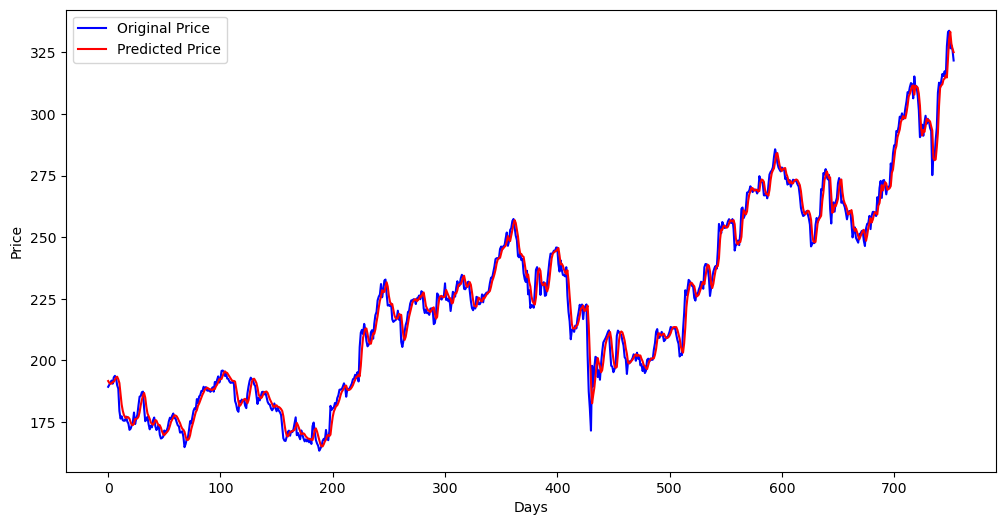

In [55]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(140.0, 300.0)

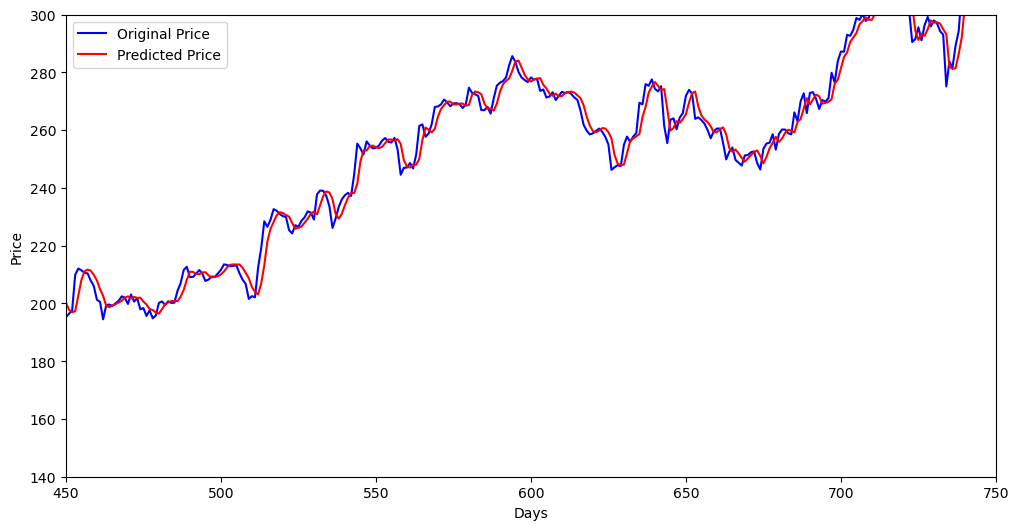

In [56]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750) #zoom in data
plt.ylim(140, 300)

# 10. Model Evaluation

In [65]:
# To check wheather model is predicted correct or wrong?
# Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [62]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error(MSE): {mse}") # if the minimum value will come means our prediction is good

Mean Squared Error(MSE): 19.6038274179424


In [63]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 4.427620965929943


In [66]:
# R-Squared
r2 = r2_score(y_test, y_predicted) # r square should be in between 0 & 1
print(f"R-Squared: {r2}") # it is near means our prediction is very good

R-Squared: 0.9870742876616989
